In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# El código configura el formato general para los números de coma flotante.
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# El script construye la ruta del archivo apuntando a la carpeta de descargas.
ruta_archivo = os.path.join(r"C:\Users\patri\Downloads", "vgsales.csv")

# El programa carga el archivo y aplica los parámetros de lectura requeridos.
df = pd.read_csv(ruta_archivo, encoding='latin1', dtype={'ITEM_CODE': str})

# 1. Para ver los datos
print(df.head())
# 2. Para ver los nombres EXACTOS de las columnas (sin recortes)
print(df.columns.tolist())

   Rank                      Name Platform     Year         Genre Publisher  \
0     1                Wii Sports      Wii 2,006.00        Sports  Nintendo   
1     2         Super Mario Bros.      NES 1,985.00      Platform  Nintendo   
2     3            Mario Kart Wii      Wii 2,008.00        Racing  Nintendo   
3     4         Wii Sports Resort      Wii 2,009.00        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB 1,996.00  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [4]:
# El código muestra el final del dataframe, una muestra aleatoria y la estadística descriptiva.
print(df.tail())
print(df.sample(5))
print(df.describe())

# El proceso valida las columnas numéricas para asegurar que las funciones operen correctamente.
columnas_numericas = df.select_dtypes(include=['number']).columns.tolist()
print("Columnas numéricas disponibles:", columnas_numericas)

# El script limpia los datos eliminando filas sin año registrado.
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

        Rank                                              Name Platform  \
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                     Men in Black II: Alien Escape       GC   
16595  16598  SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                        Know How 2       DS   
16597  16600                                  Spirits & Spells      GBA   

          Year     Genre   Publisher  NA_Sales  EU_Sales  JP_Sales  \
16593 2,002.00  Platform       Kemco      0.01      0.00      0.00   
16594 2,003.00   Shooter  Infogrames      0.01      0.00      0.00   
16595 2,008.00    Racing  Activision      0.00      0.00      0.00   
16596 2,010.00    Puzzle    7G//AMES      0.00      0.01      0.00   
16597 2,003.00  Platform     Wanadoo      0.01      0.00      0.00   

       Other_Sales  Global_Sales  
16593         0.00          0.01  
16594         0.00          0.01  
16595         0.00     

In [5]:
# El programa calcula los totales generales de juegos, géneros y plataformas.
total_juegos = df['Name'].nunique()
total_generos = df['Genre'].nunique()
total_plataformas = df['Platform'].nunique()

print(f"Total de videojuegos: {total_juegos}")
print(f"Total de géneros: {total_generos}")
print(f"Total de plataformas: {total_plataformas}")

# El código calcula el total de ventas por año desglosado por región.
ventas_por_ano = df.groupby('Year')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum()

# El script identifica el juego más vendido por año a nivel global.
idx_juegos_top = df.groupby('Year')['Global_Sales'].idxmax()
juegos_top_ano = df.loc[idx_juegos_top, ['Year', 'Name', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]

# El proceso identifica la plataforma con más ingresos por año a nivel global.
ventas_plataforma_ano = df.groupby(['Year', 'Platform'])[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum().reset_index()
idx_plat_top = ventas_plataforma_ano.groupby('Year')['Global_Sales'].idxmax()
plataformas_top_ano = ventas_plataforma_ano.loc[idx_plat_top]

Total de videojuegos: 11360
Total de géneros: 12
Total de plataformas: 31


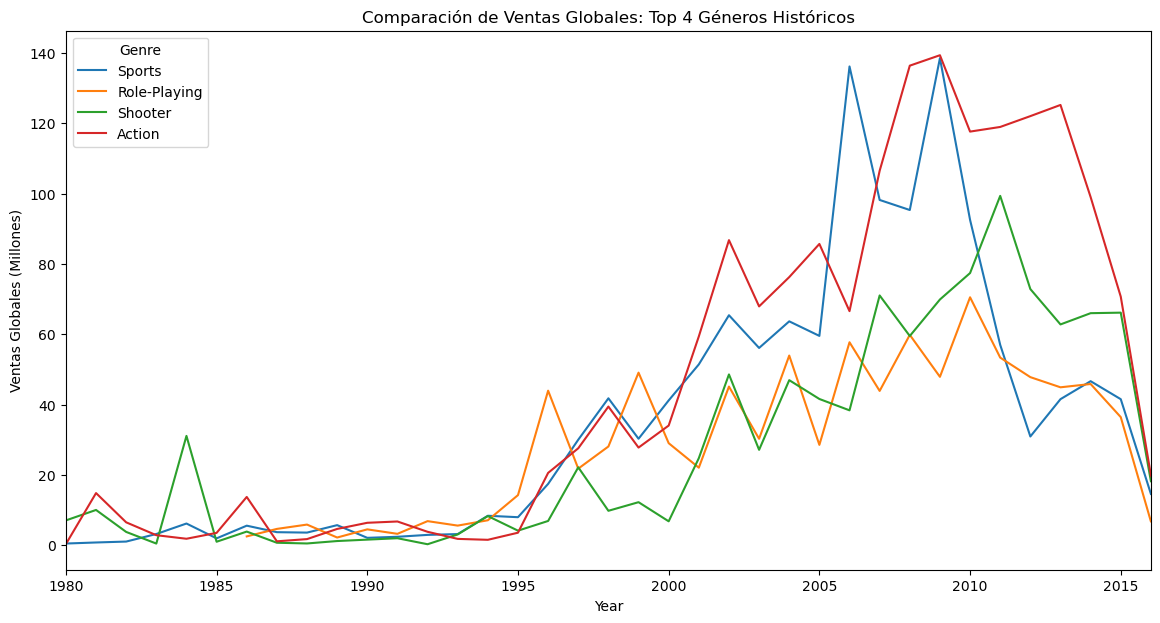

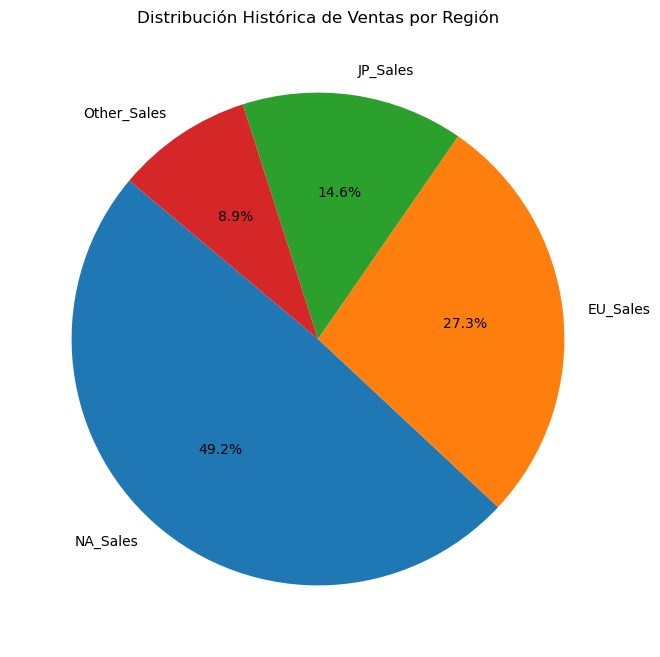

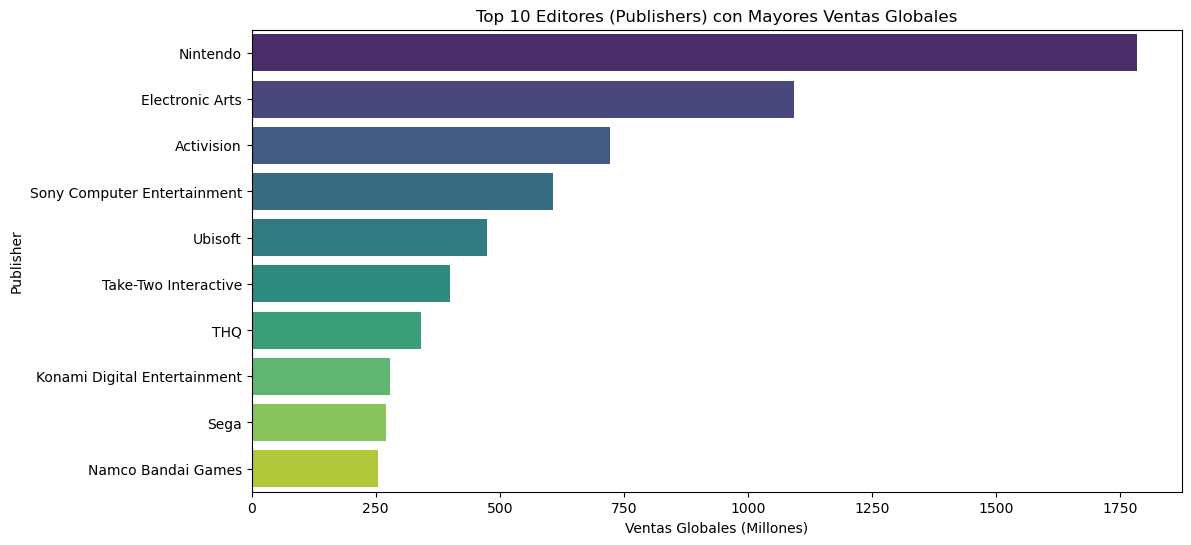

In [13]:
# El programa identifica los 4 géneros con mayores ventas históricas a nivel global.
top_4_generos = df.groupby('Genre')['Global_Sales'].sum().nlargest(4).index

# El script filtra el dataframe para conservar únicamente la información de esos 4 géneros.
df_top4 = df[df['Genre'].isin(top_4_generos)]

# El código genera un gráfico de comparación de ventas mucho más limpio y legible.
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_top4, x='Year', y='Global_Sales', hue='Genre', estimator=sum, errorbar=None)
plt.title('Comparación de Ventas Globales: Top 4 Géneros Históricos')
plt.ylabel('Ventas Globales (Millones)')
plt.xlim(1980, 2016) # El límite se ajusta a 2016 por la integridad de los datos.
plt.show()

# El script crea un gráfico de pastel para la distribución de ventas por región.
ventas_regionales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
plt.figure(figsize=(8, 8))
plt.pie(ventas_regionales, labels=ventas_regionales.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribución Histórica de Ventas por Región')
plt.show()

# El programa grafica el Top 10 de Editores solucionando la advertencia de Seaborn.
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, hue=top_publishers.index, palette='viridis', legend=False)
plt.title('Top 10 Editores (Publishers) con Mayores Ventas Globales')
plt.xlabel('Ventas Globales (Millones)')
plt.show()

In [12]:
# El algoritmo fija el año máximo a 2016 para evitar los datos residuales e incompletos del dataset original.
ano_maximo_real = 2016
df_ultimos_4 = df[(df['Year'] >= (ano_maximo_real - 3)) & (df['Year'] <= ano_maximo_real)]

# El script separa las ventas de inicio (2013) y fin (2016) del periodo.
ventas_inicio = df_ultimos_4[df_ultimos_4['Year'] == (ano_maximo_real - 3)]
ventas_fin = df_ultimos_4[df_ultimos_4['Year'] == ano_maximo_real]

# La función auxiliar calcula el crecimiento restando el inicio al final.
def calcula_crecimiento(columna):
    inicio = ventas_inicio.groupby(columna)['Global_Sales'].sum()
    fin = ventas_fin.groupby(columna)['Global_Sales'].sum()
    crecimiento = fin.sub(inicio, fill_value=0)
    return crecimiento.sort_values()

# El programa ejecuta el cálculo para géneros, plataformas y juegos.
crecimiento_genero = calcula_crecimiento('Genre')
crecimiento_plataforma = calcula_crecimiento('Platform')
crecimiento_juego = calcula_crecimiento('Name')

print(f"Género con mayor crecimiento: {crecimiento_genero.index[-1]} | Menor crecimiento: {crecimiento_genero.index[0]}")
print(f"Plataforma con mayor crecimiento: {crecimiento_plataforma.index[-1]} | Menor crecimiento: {crecimiento_plataforma.index[0]}")

# El código identifica oportunidades comparando Japón vs el resto del mundo en ese periodo.
jp_vs_resto = df_ultimos_4.groupby('Genre')[['JP_Sales', 'Global_Sales']].sum()
jp_vs_resto['Proporcion_JP'] = jp_vs_resto['JP_Sales'] / jp_vs_resto['Global_Sales']
print("\nOportunidad 1: Proporción de ventas en Japón por género (2013-2016):\n", jp_vs_resto.sort_values(by='Proporcion_JP', ascending=False).head(3))

# El proceso busca oportunidades calculando las ventas promedio por juego.
calidad_plataforma = df_ultimos_4.groupby('Platform')['Global_Sales'].mean().sort_values(ascending=False)
print("\nOportunidad 2: Plataformas con mayores ventas promedio por juego (2013-2016):\n", calidad_plataforma.head(3))

Género con mayor crecimiento: Puzzle | Menor crecimiento: Action
Plataforma con mayor crecimiento: PS4 | Menor crecimiento: PS3

Oportunidad 1: Proporción de ventas en Japón por género (2013-2016):
               JP_Sales  Global_Sales  Proporcion_JP
Genre                                              
Puzzle            1.18          3.19           0.37
Role-Playing     47.91        133.98           0.36
Adventure         5.59         22.51           0.25

Oportunidad 2: Plataformas con mayores ventas promedio por juego (2013-2016):
 Platform
PS4    0.83
X360   0.74
Wii    0.70
Name: Global_Sales, dtype: float64


In [19]:
# ==============================================================================
# GRÁFICO 1: Histórico - Evolución del Top 4 de Géneros
# ==============================================================================
# El programa identifica los 4 géneros líderes históricos.
top_4_generos = df.groupby('Genre')['Global_Sales'].sum().nlargest(4).index
df_top4 = df[df['Genre'].isin(top_4_generos)]

# Crea el gráfico de líneas.
plt.figure(figsize=(12, 6))
plot1 = sns.lineplot(data=df_top4, x='Year', y='Global_Sales', hue='Genre', estimator=sum, errorbar=None)
plt.title('Comparación de Ventas Globales: Top 4 Géneros Históricos (1980-2016)', fontsize=14)
plt.ylabel('Ventas Globales (Millones)', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.xlim(1980, 2016) # Ajuste de integridad de datos.
plt.legend(title='Género')

# Guarda la imagen en Descargas.
ruta_grafico1 = os.path.join(ruta_descargas, "grafico_1_historico_generos.png")
plt.savefig(ruta_grafico1, dpi=300, bbox_inches='tight') # Alta resolución y sin bordes blancos.
plt.close() # Cierra la figura para liberar memoria.


# ==============================================================================
# GRÁFICO 2: Crecimiento Reciente - Batalla de Consolas (2013-2016)
# ==============================================================================
# Prepara los datos de crecimiento por plataforma.
ventas_inicio_plat = df_ultimos_4[df_ultimos_4['Year'] == 2013].groupby('Platform')['Global_Sales'].sum()
ventas_fin_plat = df_ultimos_4[df_ultimos_4['Year'] == 2016].groupby('Platform')['Global_Sales'].sum()
crecimiento_plat = (ventas_fin_plat - ventas_inicio_plat).dropna().sort_values()

# Crea el gráfico de barras.
plt.figure(figsize=(12, 6))
sns.barplot(x=crecimiento_plat.index, y=crecimiento_plat.values, hue=crecimiento_plat.index, palette='coolwarm', legend=False)
plt.title('Crecimiento Neto de Ventas Globales por Plataforma (2013 vs 2016)', fontsize=14)
plt.ylabel('Diferencia de Ventas (Millones)', fontsize=12)
plt.xlabel('Plataforma', fontsize=12)
plt.axhline(0, color='black', linewidth=1) # Línea de referencia en cero.

# Guarda la imagen.
ruta_grafico2 = os.path.join(ruta_descargas, "grafico_2_crecimiento_plataformas.png")
plt.savefig(ruta_grafico2, dpi=300, bbox_inches='tight')
plt.close()


# ==============================================================================
# GRÁFICO 3: Oportunidad de Mercado - Concentración en Japón
# ==============================================================================
# Usamos los datos exactos que calculaste en tu notebook para Oportunidad 1.
# Prepara datos para gráfico de barras apiladas al 100%.
jp_oportunidad = df_ultimos_4.groupby('Genre')[['JP_Sales', 'Global_Sales']].sum()
jp_oportunidad['Resto_World_Sales'] = jp_oportunidad['Global_Sales'] - jp_oportunidad['JP_Sales']
# Filtra solo los top para Japón (RPG, Puzzle, Action) basados en tu output.
top_jp_genres = ['Role-Playing', 'Puzzle', 'Action']
jp_oportunidad_plot = jp_oportunidad.loc[top_jp_genres]

# Crea el gráfico de barras apiladas.
plt.figure(figsize=(10, 6))
# Barra del Resto del Mundo (fondo).
sns.barplot(x=jp_oportunidad_plot.index, y=jp_oportunidad_plot['Global_Sales'], color='lightgrey', label='Resto del Mundo')
# Barra de Japón (encima).
sns.barplot(x=jp_oportunidad_plot.index, y=jp_oportunidad_plot['JP_Sales'], color='crimson', label='Japón')

plt.title('Proporción de Ventas en Japón vs Global por Género (2013-2016)', fontsize=14)
plt.ylabel('Ventas Globales Totales (Millones)', fontsize=12)
plt.xlabel('Género', fontsize=12)
plt.legend()

# Guarda la imagen.
ruta_grafico3 = os.path.join(ruta_descargas, "grafico_3_oportunidad_japon.png")
plt.savefig(ruta_grafico3, dpi=300, bbox_inches='tight')
plt.close()

print(f"¡Éxito! Se han guardado 3 imágenes .png en tu carpeta de descargas.")
print(f"Ahora solo arrástralas a tus diapositivas vacías.")

¡Éxito! Se han guardado 3 imágenes .png en tu carpeta de descargas.
Ahora solo arrástralas a tus diapositivas vacías.
